
# Manual picking of the four main BCHH events on six channels

This notebook is designed to verify the relative arrival times of the four main
Falcon 9 AMOS-6 events by **manually picking each event on each of the six BCHH
channels**: three pressure channels and three seismic channels.

The main output is a tidy `pandas.DataFrame` with one row per event/channel pick,
plus CSV files containing the individual UTC picks, same-trace event intervals,
and robust summaries across channels.

For the shock-wave question, the most useful quantities are **differential
arrival times on the same trace**, because fixed channel delays cancel.

The picker uses the `ipympl` matplotlib backend. If necessary:

```bash
conda install -c conda-forge ipympl ipywidgets
```

or:

```bash
pip install ipympl ipywidgets
```

Then restart the notebook kernel.


In [1]:

%matplotlib widget

from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets

from obspy import UTCDateTime, Stream
from obspy.clients.filesystem.sds import Client as SDSClient


## 1. Configuration

In [2]:

# -------------------------------------------------------------------------
# USER CONFIGURATION
# -------------------------------------------------------------------------

# Root of the SDS archive, e.g.
# SDS_ROOT = Path("/Volumes/KSCGTdownld/SDS")
SDS_ROOT = Path("/Volumes/haldata/remastered/SDS_KSC")

NETWORK = "*"       # set explicitly if desired
STATION = "BCHH"
LOCATION = "*"      # "" / "00" / "*" depending on archive

# Approximate BCHH ARRIVAL times only.
# These just centre the plots; your manual picks determine the final times.
EVENTS = {
    "upper_stage":       UTCDateTime("2016-09-01T13:07:15.96"),
    "principal":         UTCDateTime("2016-09-01T13:07:19.56"),
    "payload_impact":    UTCDateTime("2016-09-01T13:07:28.47"),
    "payload_explosion": UTCDateTime("2016-09-01T13:07:29.03"),
}

PRE_S = 1.0
POST_S = 1.0

# Optional zero-phase display filtering.
# No response removal is done in this notebook.
APPLY_DISPLAY_FILTER = True
PRESSURE_FILTER_HZ = (0.5, 80.0)
SEISMIC_FILTER_HZ = (0.5, 80.0)

OUTPUT_DIR = Path("./manual_picks_bchh")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PICKS_CSV = OUTPUT_DIR / "bchh_four_event_manual_picks.csv"
INTERVALS_CSV = OUTPUT_DIR / "bchh_four_event_intervals_by_trace.csv"
SUMMARY_CSV = OUTPUT_DIR / "bchh_four_event_interval_summary.csv"

print("SDS_ROOT:", SDS_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


SDS_ROOT: /Volumes/haldata/remastered/SDS_KSC
OUTPUT_DIR: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/notebooks/manual_picks_bchh



## 2. Discover BCHH channels

Run this over a short sequence window. Inspect the IDs, then set the exact six
trace IDs in the next section. The notebook deliberately does not guess which
codes correspond to your three microphones and three seismic components.


In [ ]:

client = SDSClient(str(SDS_ROOT))

t0 = min(EVENTS.values()) - 5
t1 = max(EVENTS.values()) + 5

st_all = client.get_waveforms(
    NETWORK, STATION, LOCATION, "*", t0, t1
)
st_all.sort()

print(f"Loaded {len(st_all)} trace segment(s)\n")
for tr in st_all:
    print(
        f"{tr.id:24s} "
        f"sr={tr.stats.sampling_rate:8.2f} Hz  "
        f"{tr.stats.starttime}  ->  {tr.stats.endtime}"
    )


In [ ]:
st_all.write('/Users/thompsong/Downloads/bchh_20160901_23s.mseed')

In [3]:
import obspy
st_all = obspy.read('/Users/thompsong/Downloads/bchh_20160901_23s.mseed')


## 3. Select the six traces

Set the exact three pressure IDs and three seismic IDs from the discovery output.
The order below is the order used in the picking figure.


In [4]:
TRACE_IDS = [
    "1R.BCHH.10.DD1",
    "1R.BCHH.10.DD2",
    "1R.BCHH.10.DD3",
    "1R.BCHH.10.DHE",
    "1R.BCHH.10.DHN",
    "1R.BCHH.10.DHZ",
]

TRACE_KIND = {
    "1R.BCHH.10.DD1": "pressure",
    "1R.BCHH.10.DD2": "pressure",
    "1R.BCHH.10.DD3": "pressure",
    "1R.BCHH.10.DHE": "seismic",
    "1R.BCHH.10.DHN": "seismic",
    "1R.BCHH.10.DHZ": "seismic",
}

missing = [tid for tid in TRACE_IDS if tid not in TRACE_KIND]
if missing:
    raise ValueError(f"TRACE_KIND missing: {missing}")

for tid in TRACE_IDS:
    print(f"{tid:24s} {TRACE_KIND[tid]}")

1R.BCHH.10.DD1           pressure
1R.BCHH.10.DD2           pressure
1R.BCHH.10.DD3           pressure
1R.BCHH.10.DHE           seismic
1R.BCHH.10.DHN           seismic
1R.BCHH.10.DHZ           seismic


## 4. Load and prepare the selected traces

In [5]:

def get_trace_by_id(stream: Stream, trace_id: str):
    parts = trace_id.split(".")
    if len(parts) != 4:
        raise ValueError(f"Expected NET.STA.LOC.CHA, got {trace_id!r}")
    net, sta, loc, cha = parts
    sub = stream.select(
        network=net, station=sta, location=loc, channel=cha
    ).copy()
    if len(sub) == 0:
        raise KeyError(f"No trace found for {trace_id}")
    sub.merge(method=1, fill_value="interpolate")
    if len(sub) != 1:
        raise RuntimeError(f"Could not merge {trace_id} to one trace")
    return sub[0]


def make_display_trace(tr, kind, apply_filter=True):
    out = tr.copy()
    out.detrend("demean")
    out.detrend("linear")

    if apply_filter:
        fmin, fmax = (
            PRESSURE_FILTER_HZ if kind == "pressure" else SEISMIC_FILTER_HZ
        )
        nyq = 0.5 * out.stats.sampling_rate
        fmax_use = min(fmax, 0.95 * nyq)

        if fmax_use > fmin > 0:
            out.filter(
                "bandpass",
                freqmin=fmin,
                freqmax=fmax_use,
                corners=4,
                zerophase=True,
            )
        elif fmin > 0:
            out.filter("highpass", freq=fmin, corners=4, zerophase=True)

    return out


if len(TRACE_IDS) == 6:
    selected_raw = Stream([get_trace_by_id(st_all, tid) for tid in TRACE_IDS])

    display_traces = {
        tid: make_display_trace(
            get_trace_by_id(selected_raw, tid),
            TRACE_KIND[tid],
            apply_filter=APPLY_DISPLAY_FILTER,
        )
        for tid in TRACE_IDS
    }

    for tid in TRACE_IDS:
        tr = display_traces[tid]
        print(
            f"{tid:24s} {tr.stats.npts:8d} samples "
            f"@ {tr.stats.sampling_rate:g} Hz"
        )


1R.BCHH.10.DD1               5768 samples @ 250 Hz
1R.BCHH.10.DD2               5768 samples @ 250 Hz
1R.BCHH.10.DD3               5768 samples @ 250 Hz
1R.BCHH.10.DHE               5768 samples @ 250 Hz
1R.BCHH.10.DHN               5768 samples @ 250 Hz
1R.BCHH.10.DHZ               5768 samples @ 250 Hz



## 5. Interactive six-trace picker

For each event:

1. choose the event in the dropdown;
2. left-click each trace at the arrival you want to pick;
3. clicking the same trace again replaces that pick;
4. use **Clear current trace** or **Clear event** when needed;
5. click **Save picks**.

The dashed line is only the approximate plot centre. The red line is your pick.

For differential timing, consistency of the picked physical phase on a given
trace is more important than forcing all channels to have identical absolute
arrival times.


Text(value='', description='Notes:', layout=Layout(width='700px'))

HTML(value='')

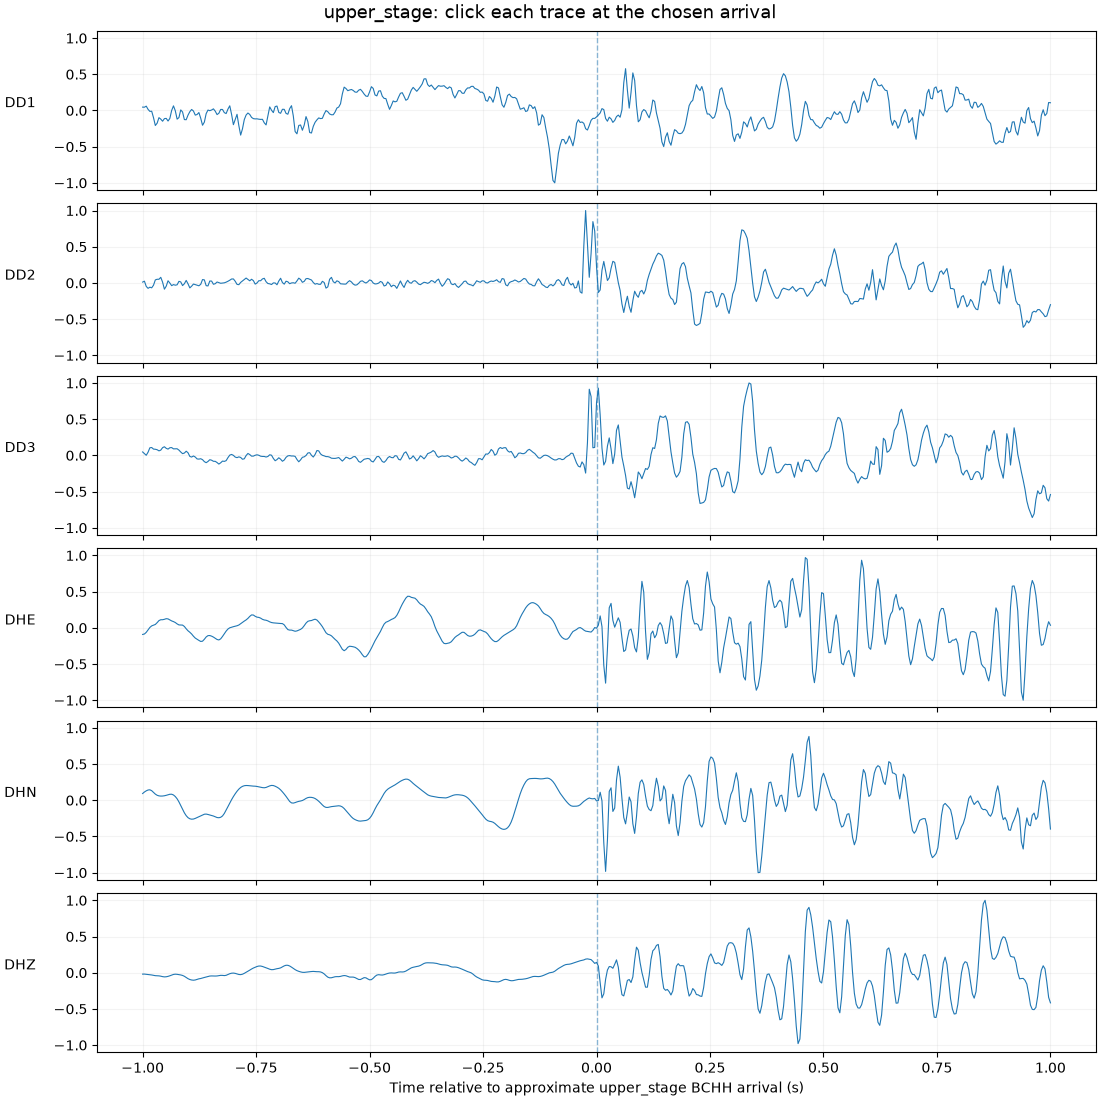

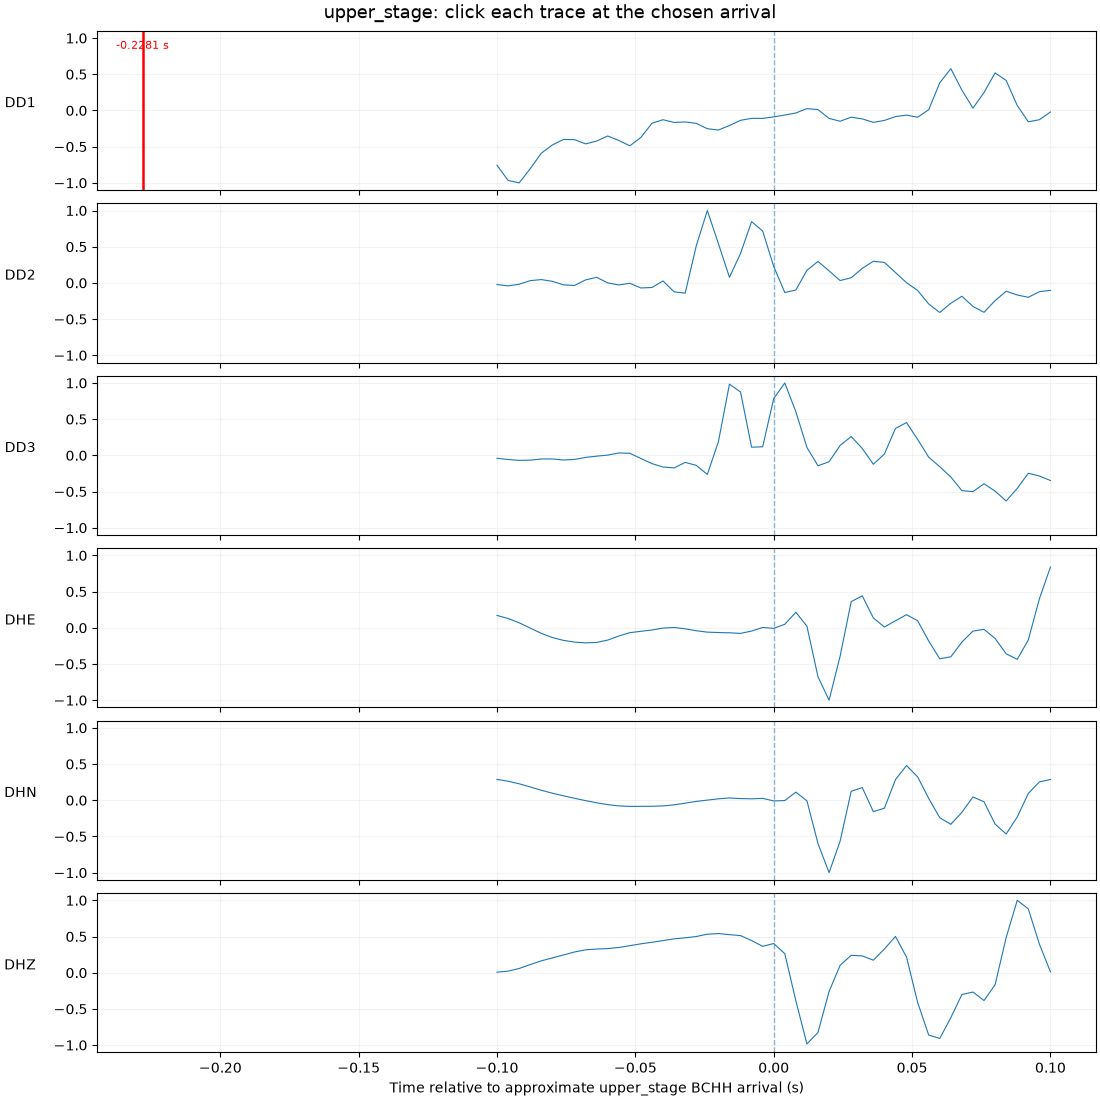

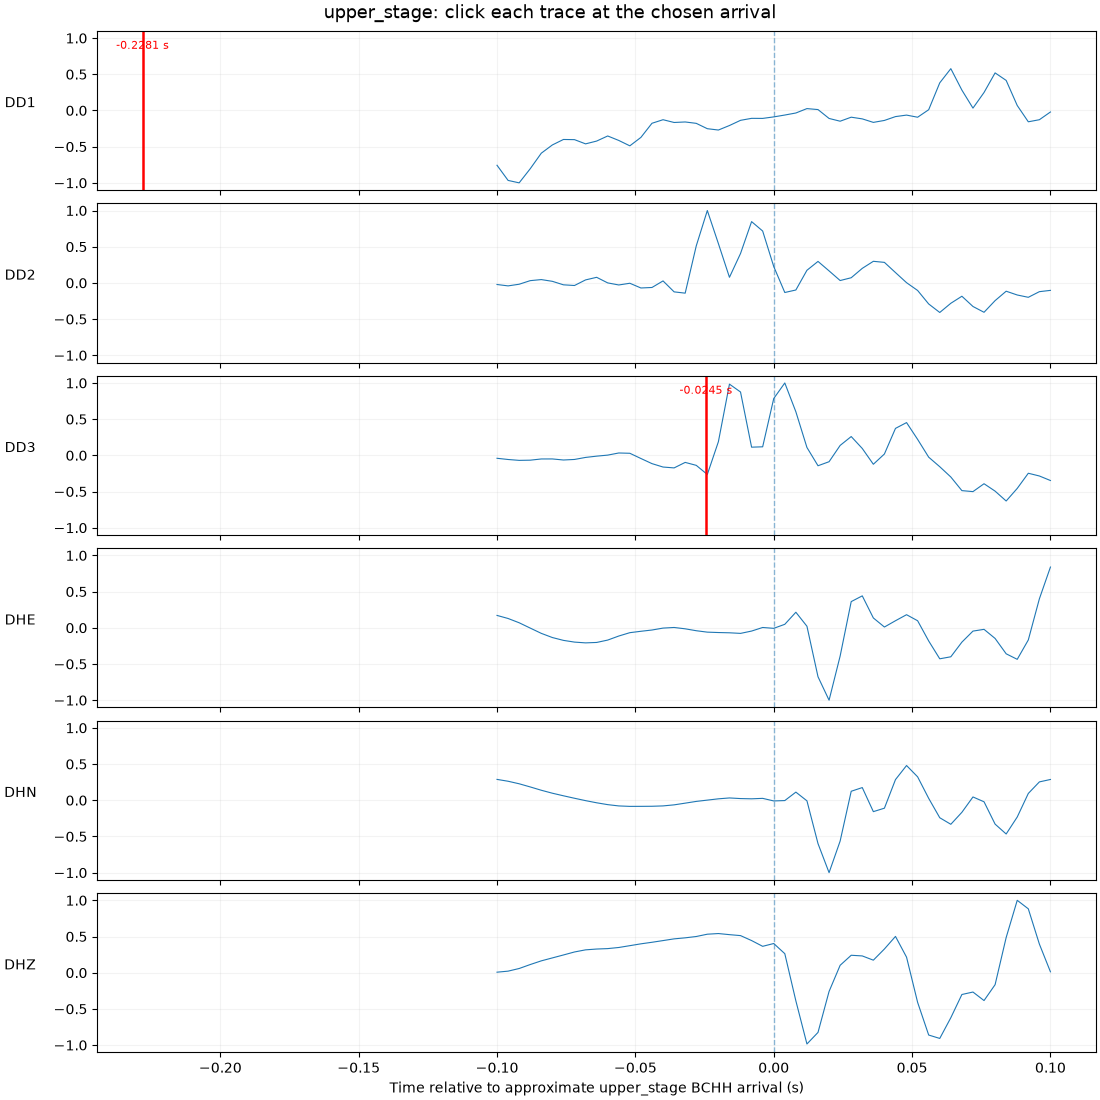

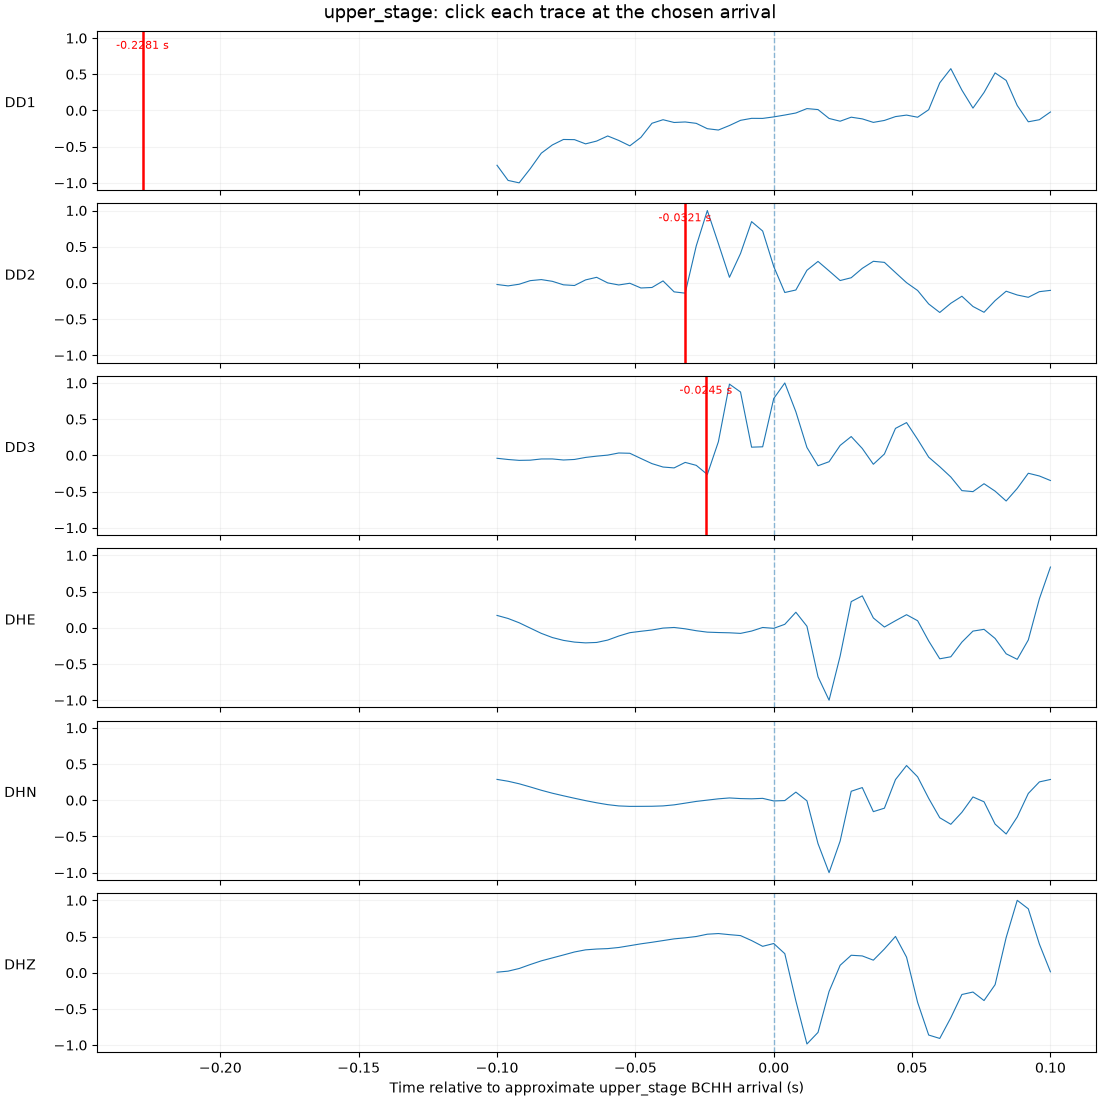

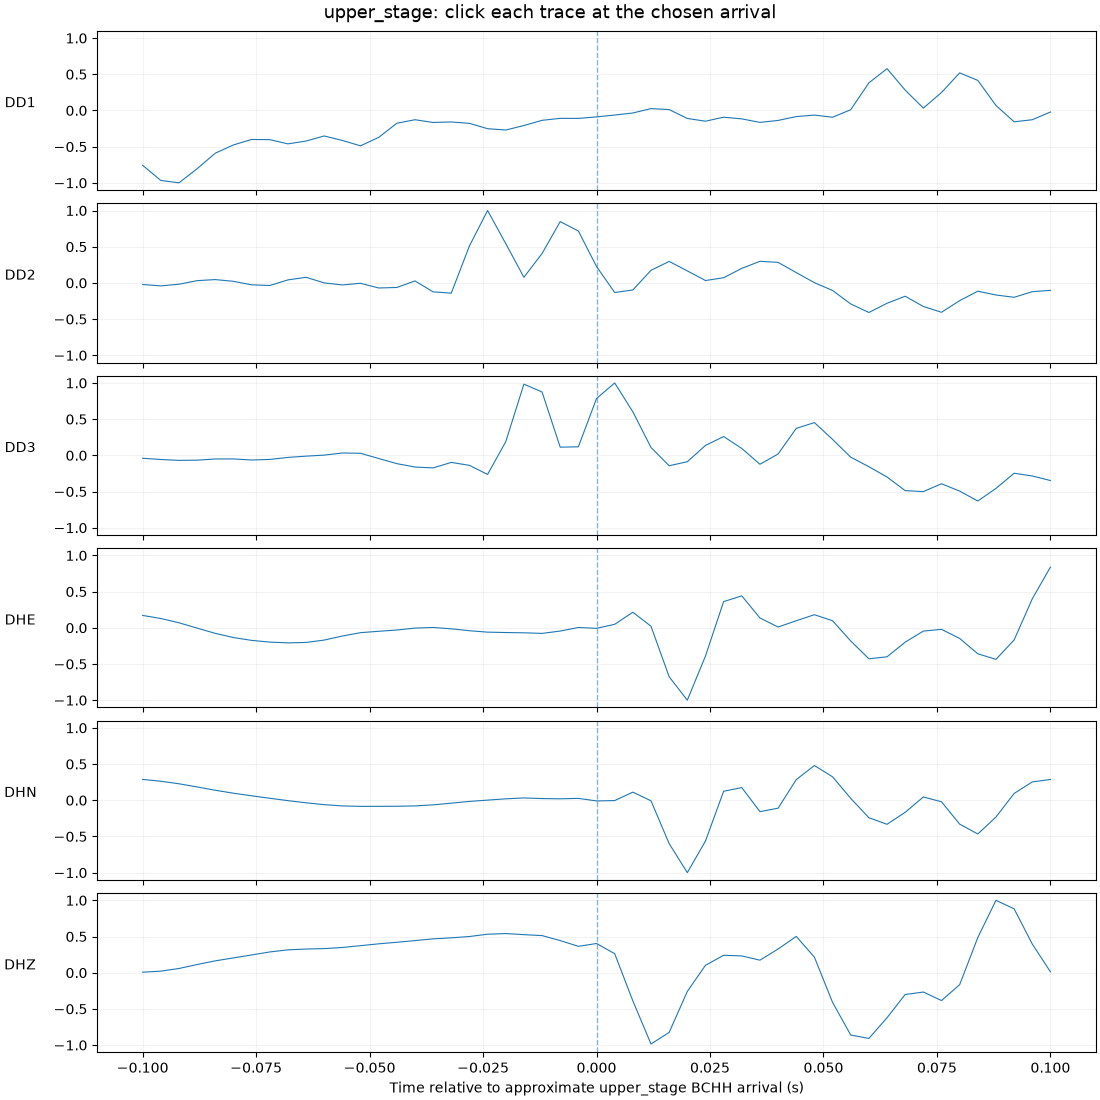

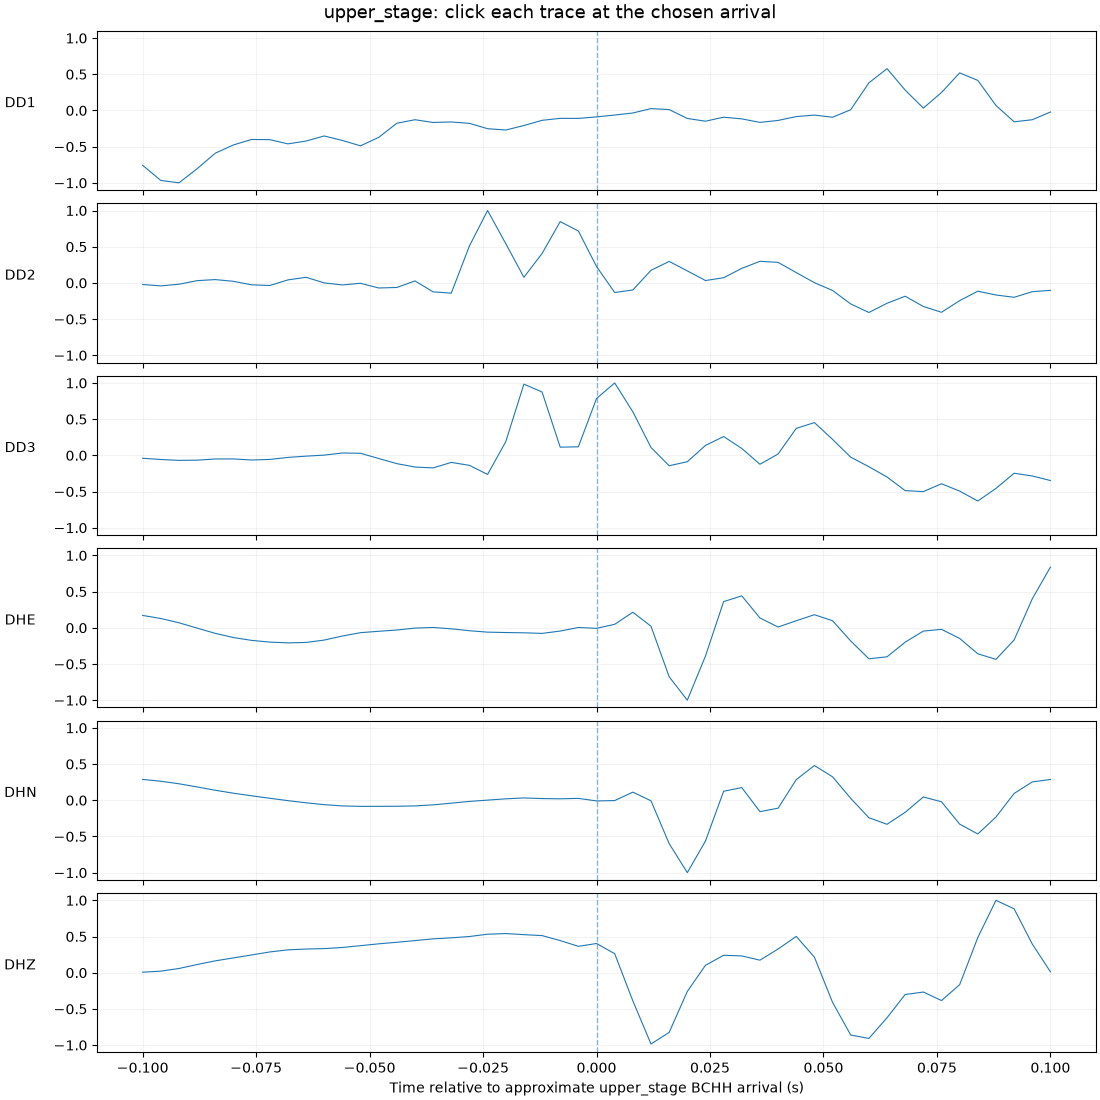

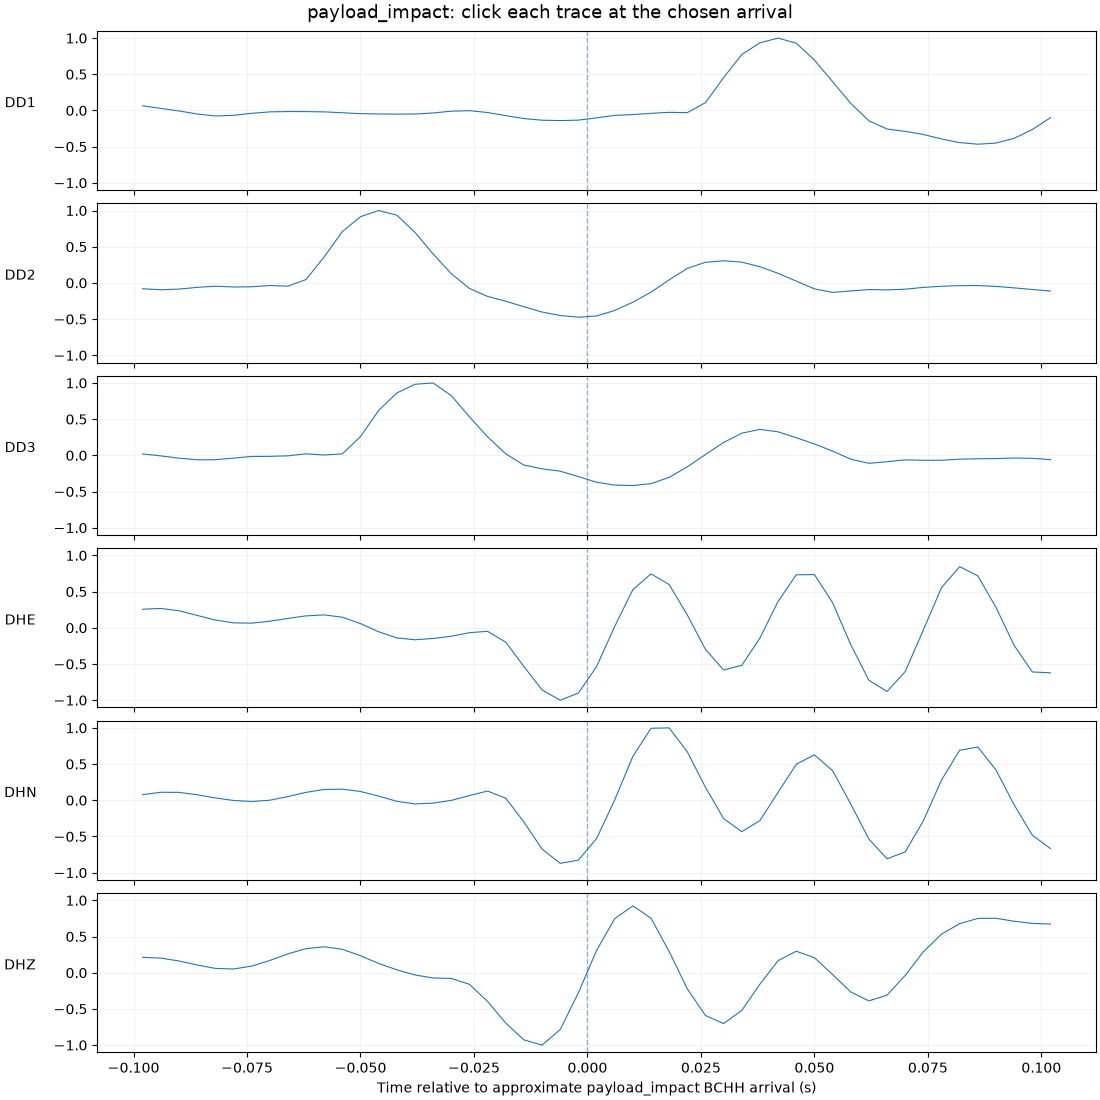

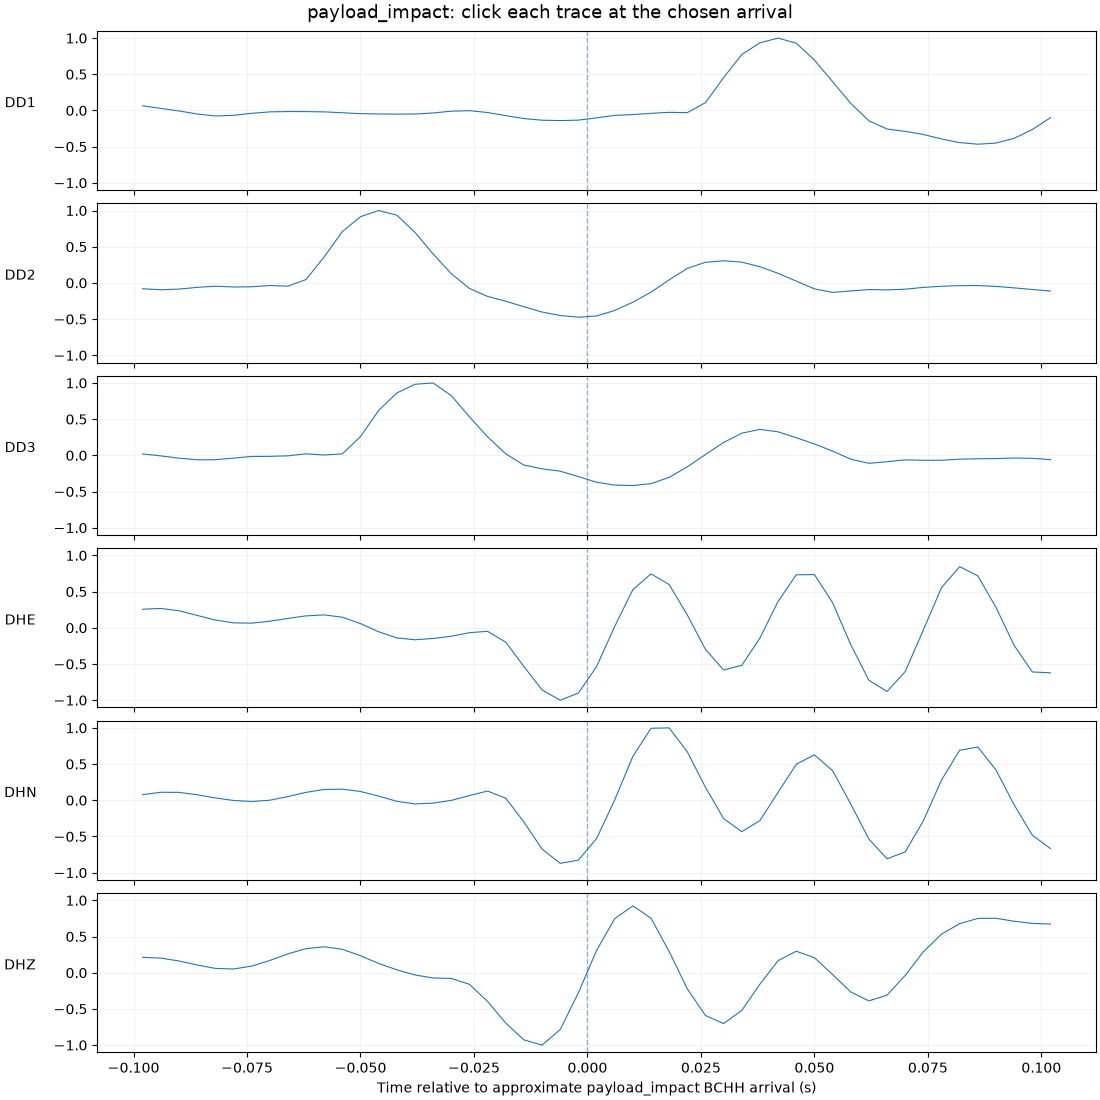

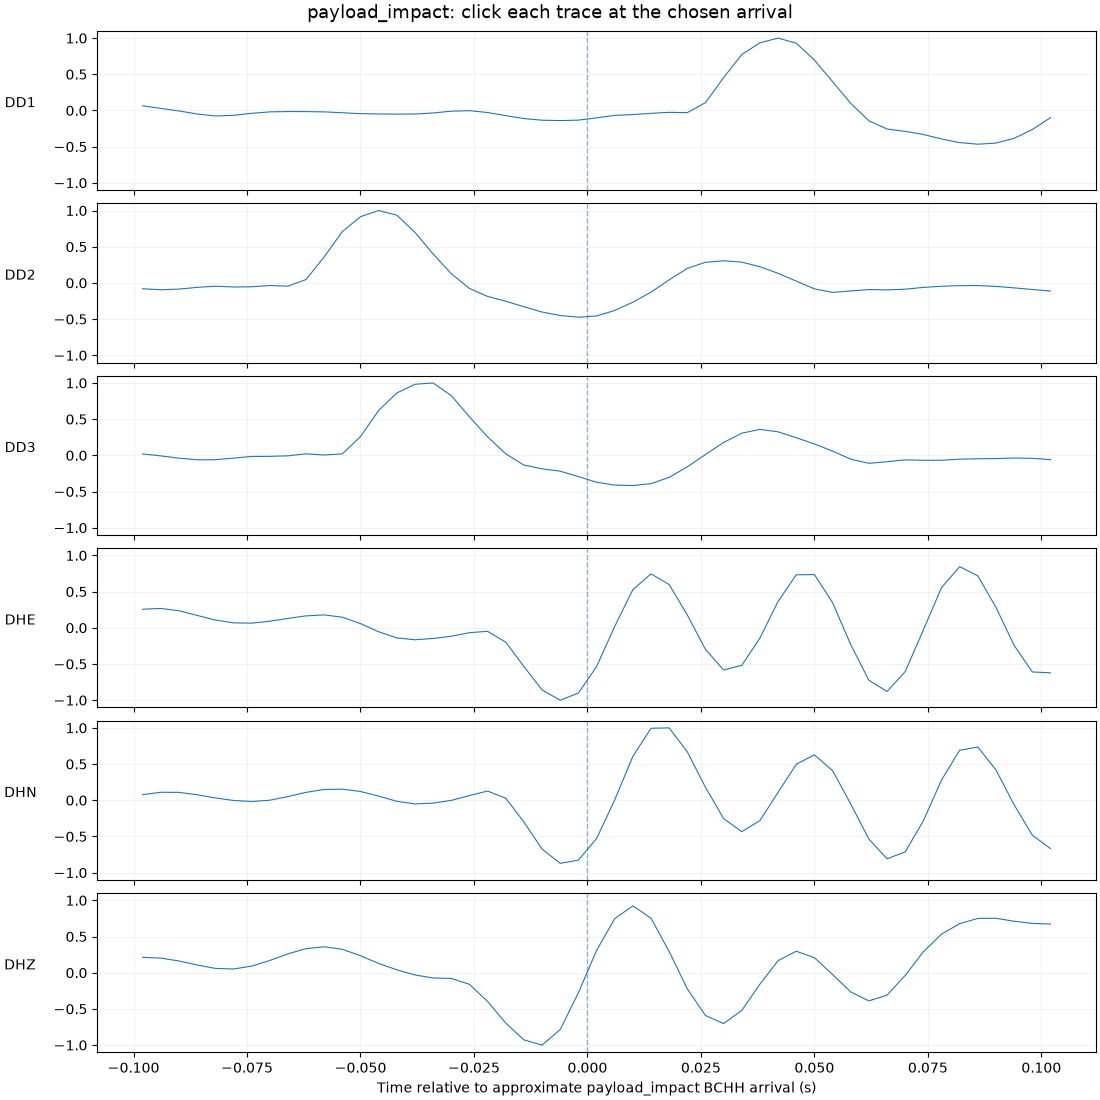

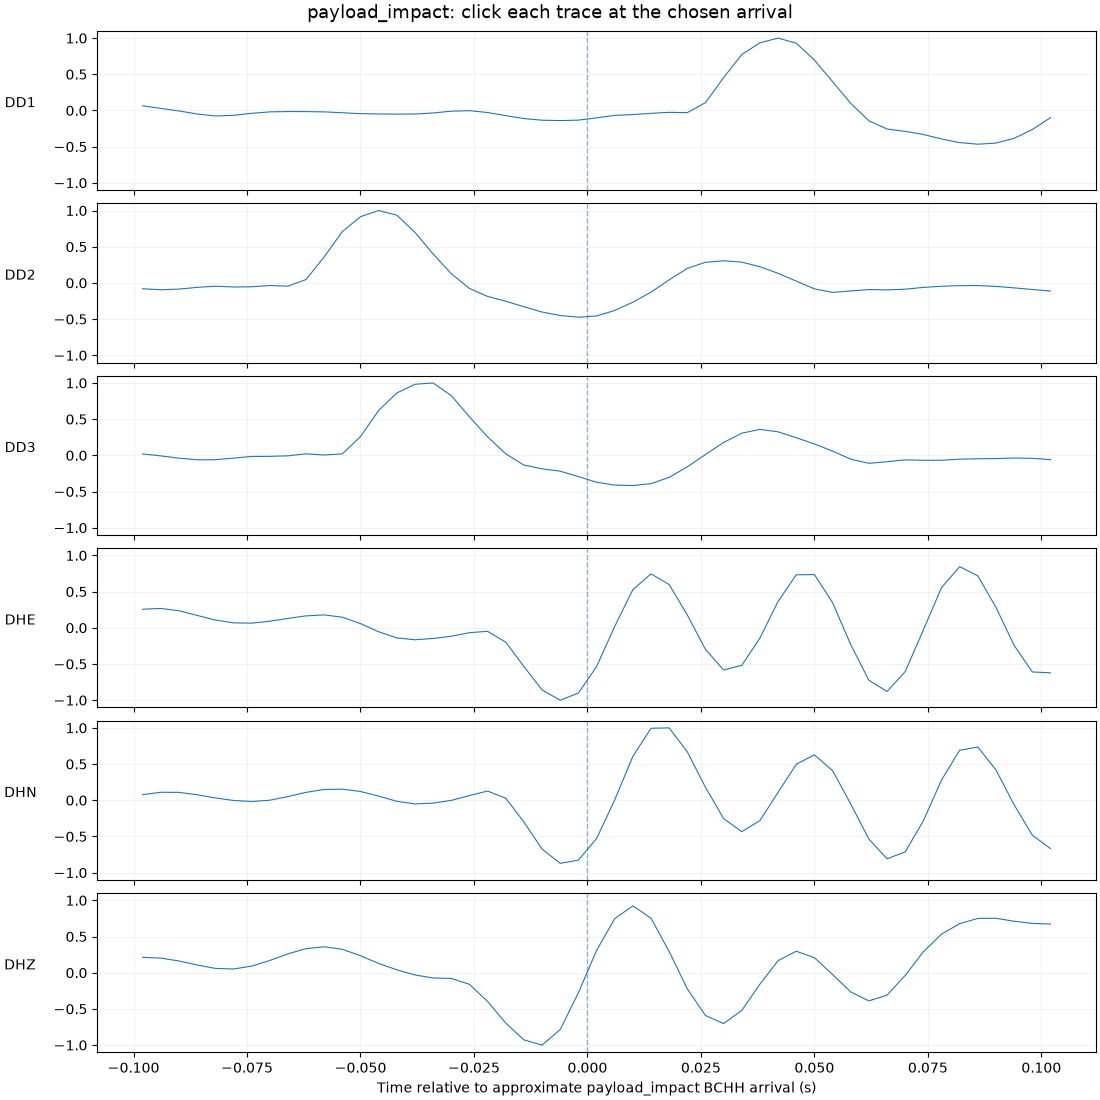

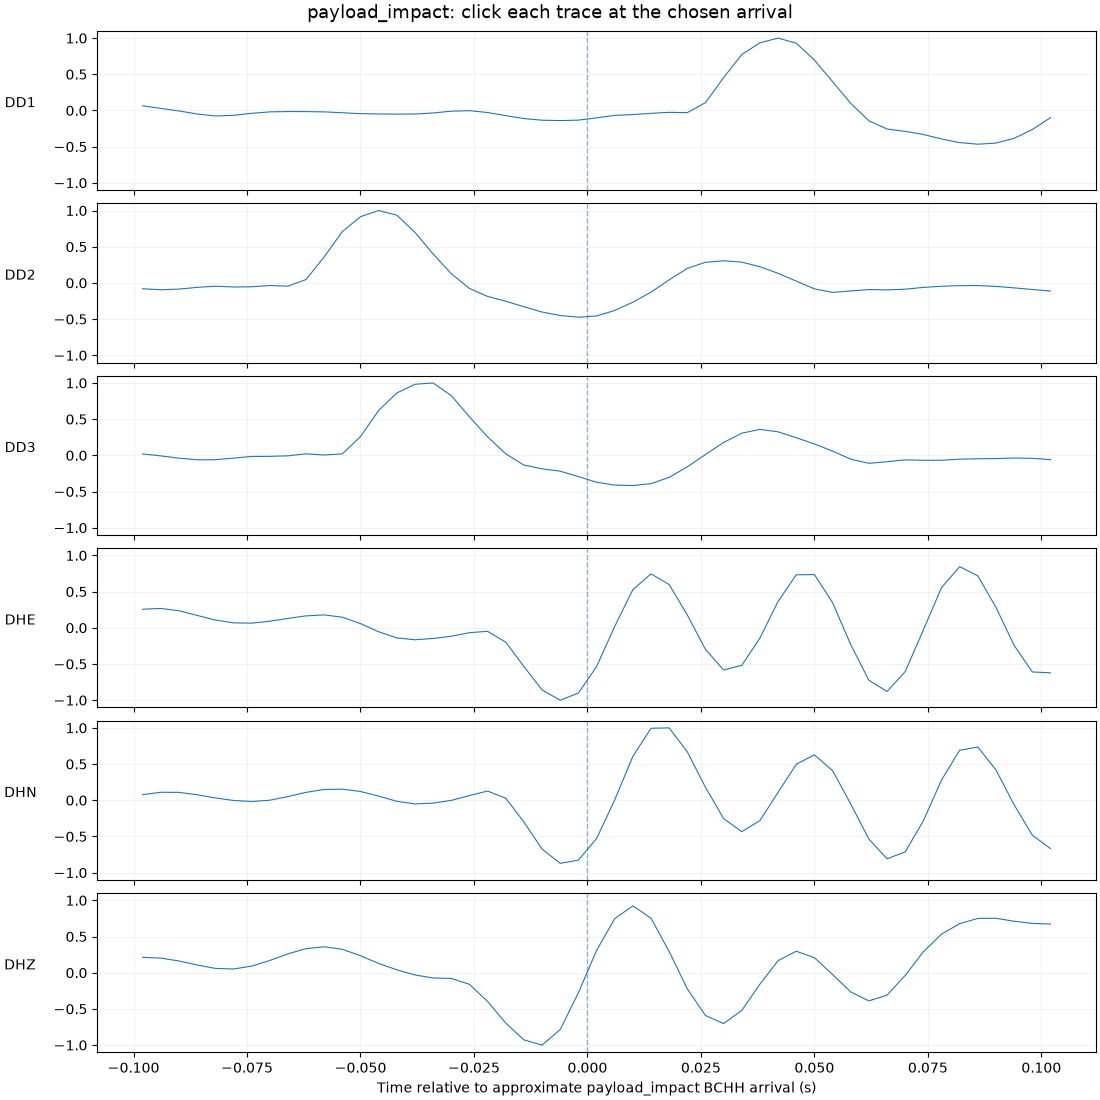

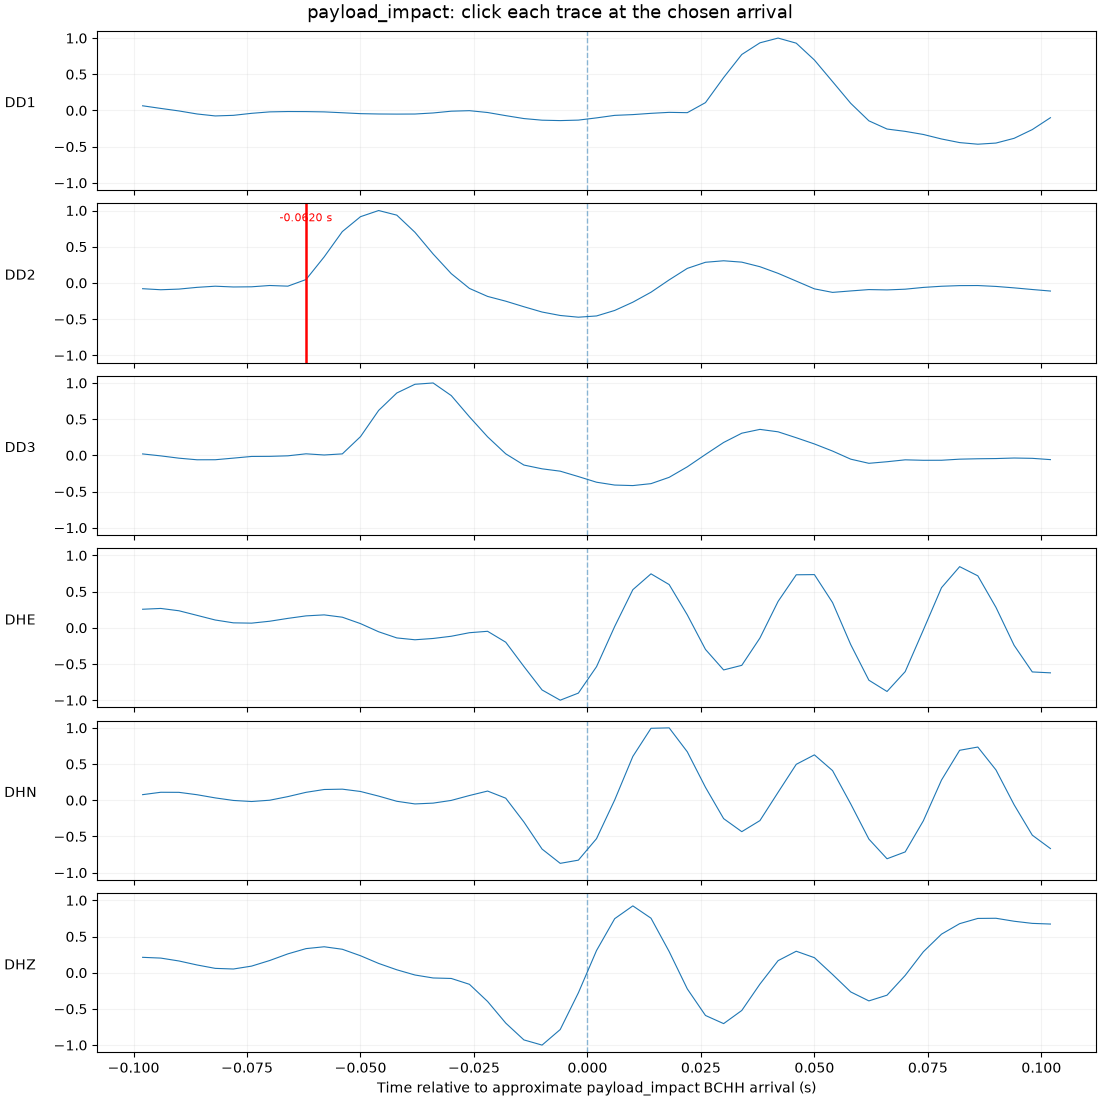

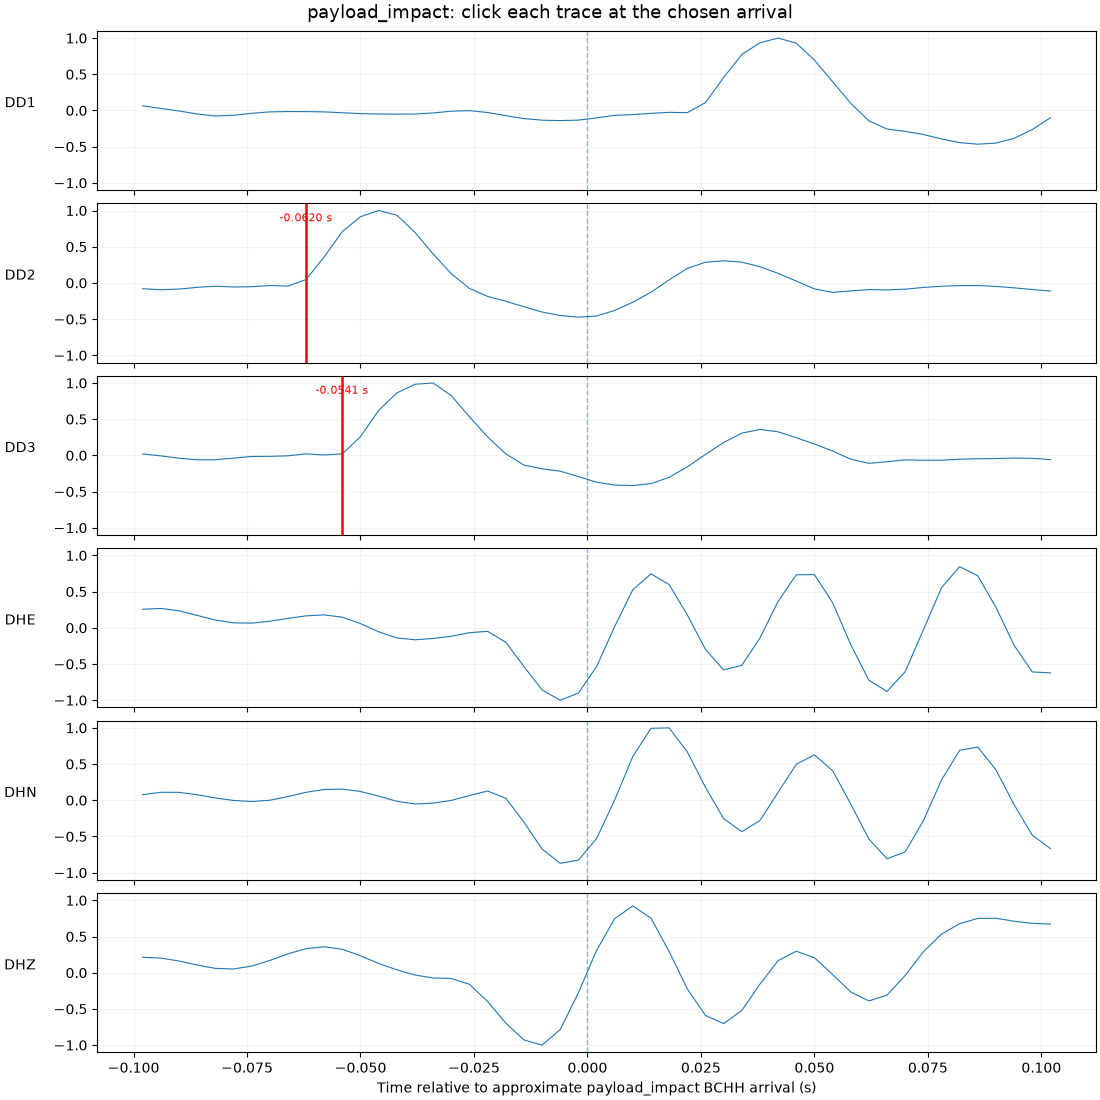

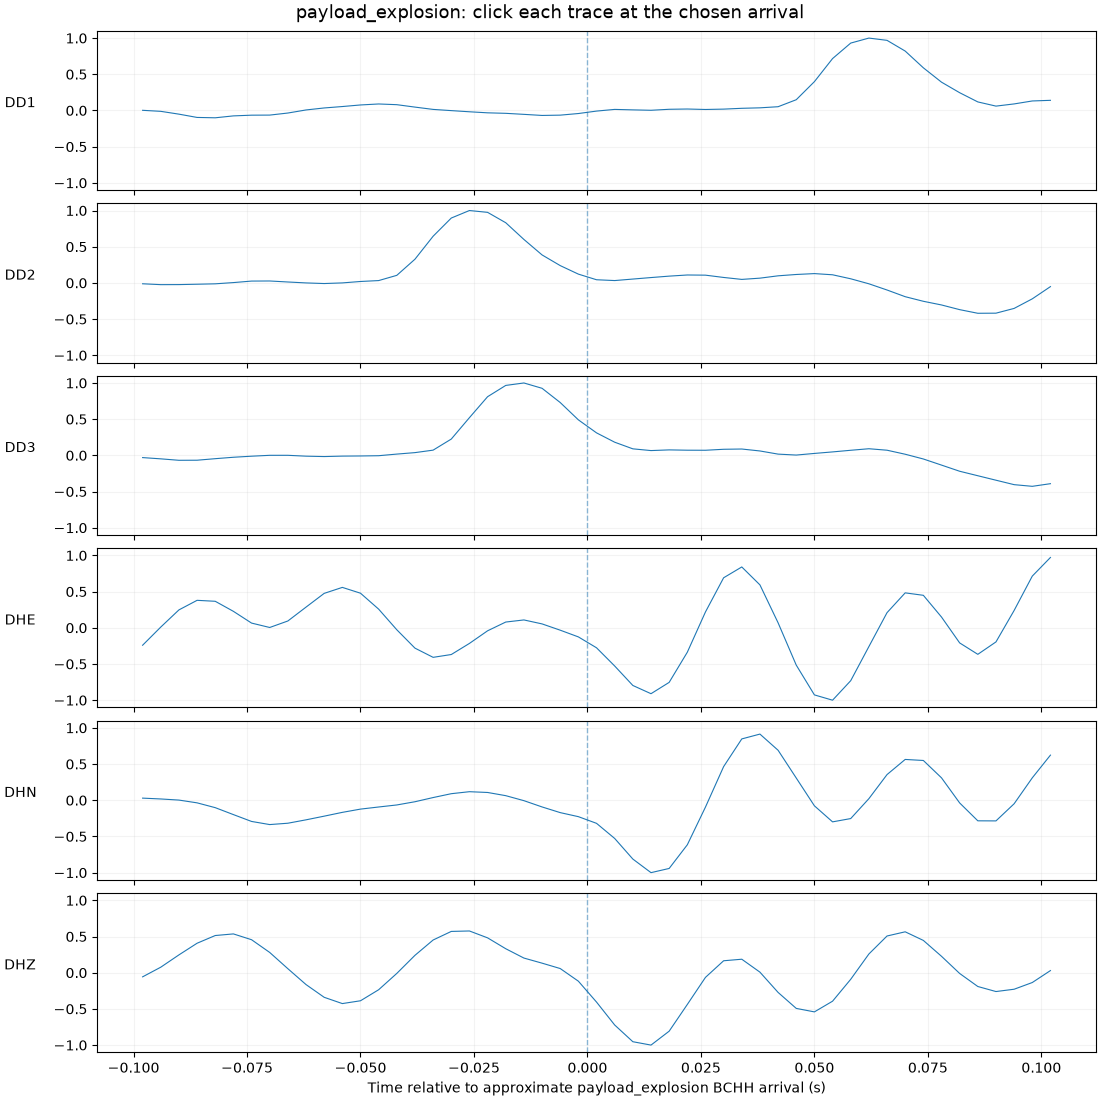

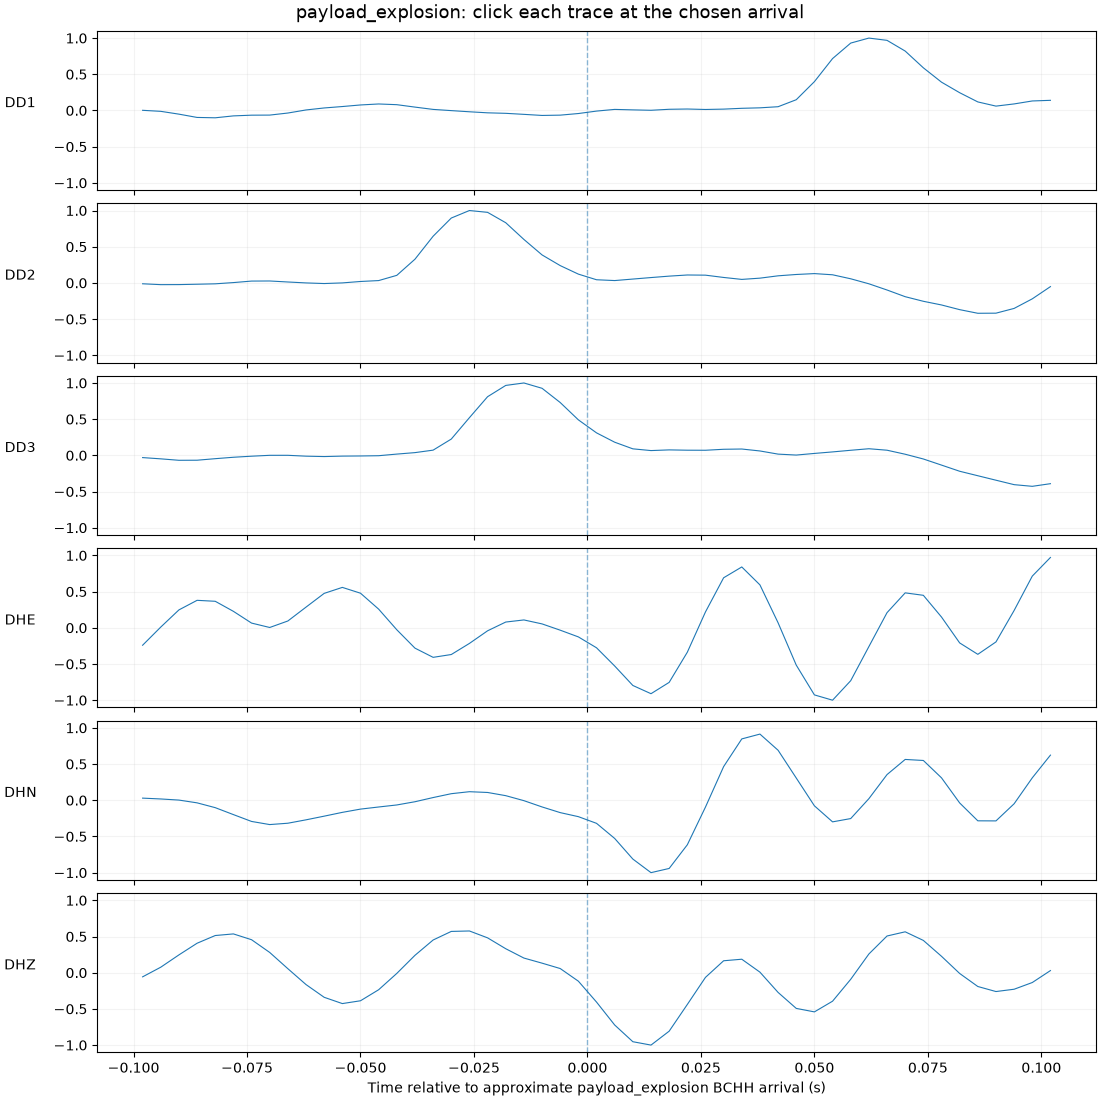

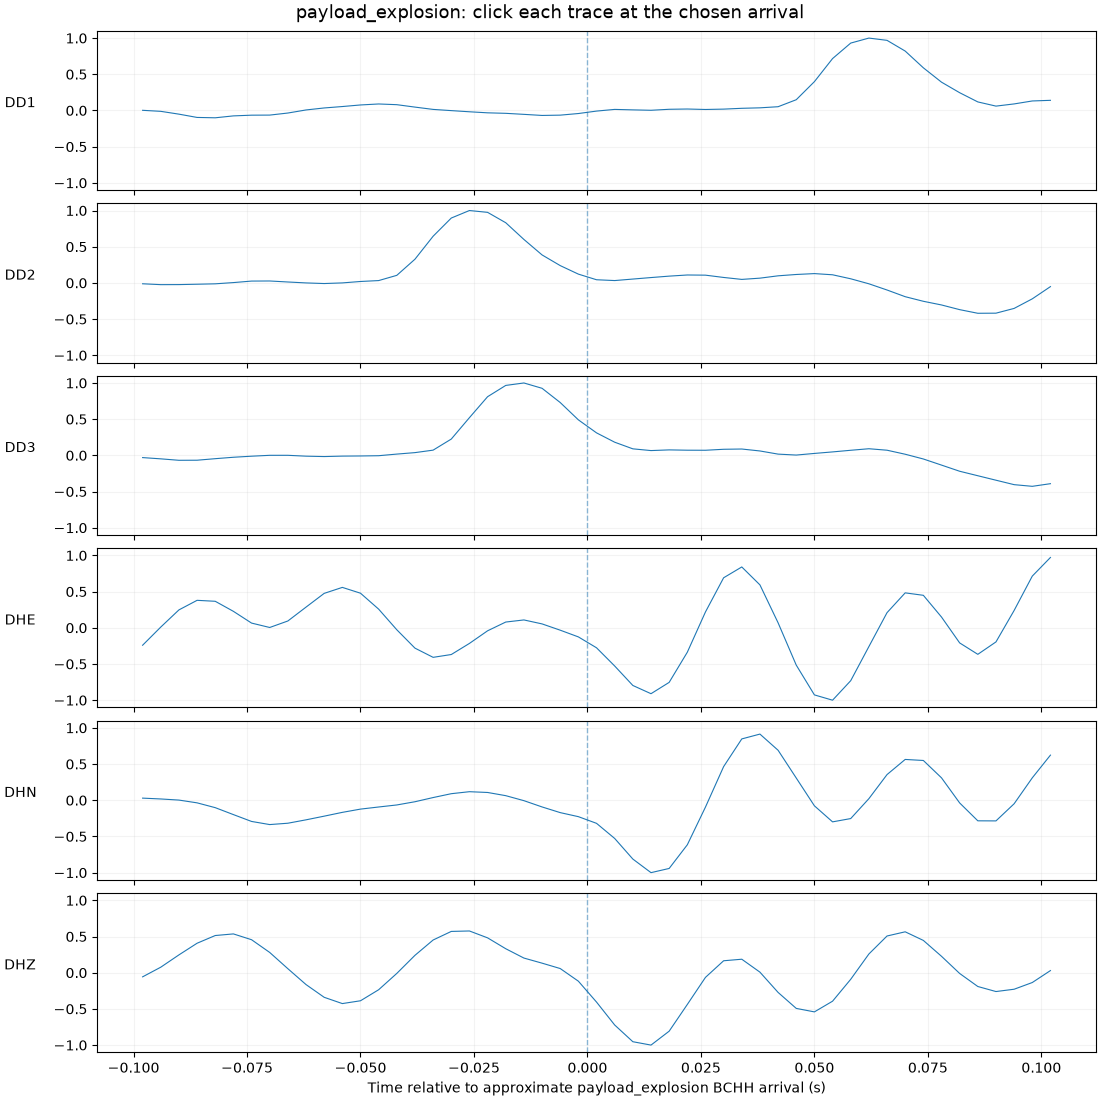

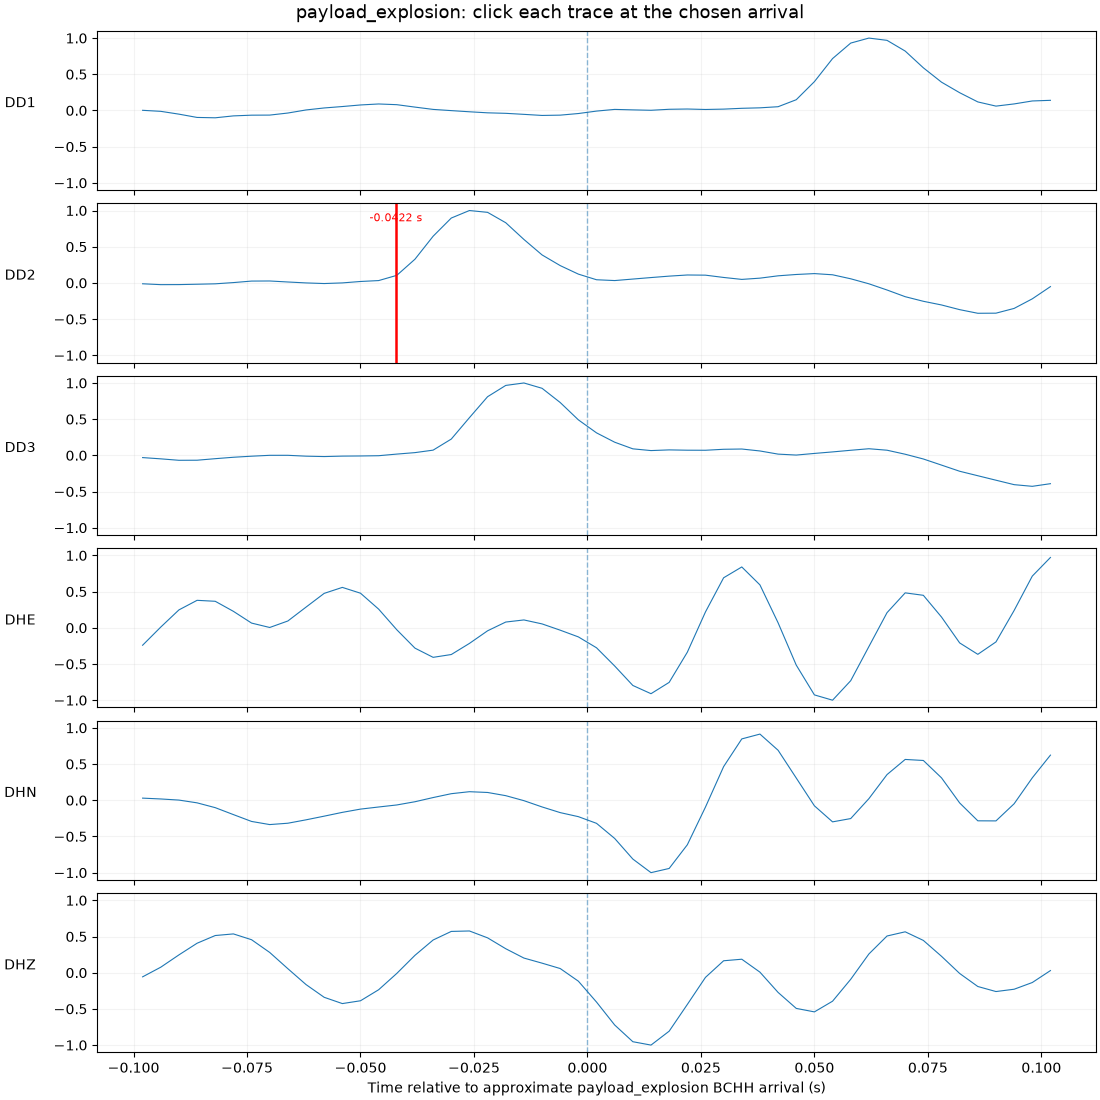

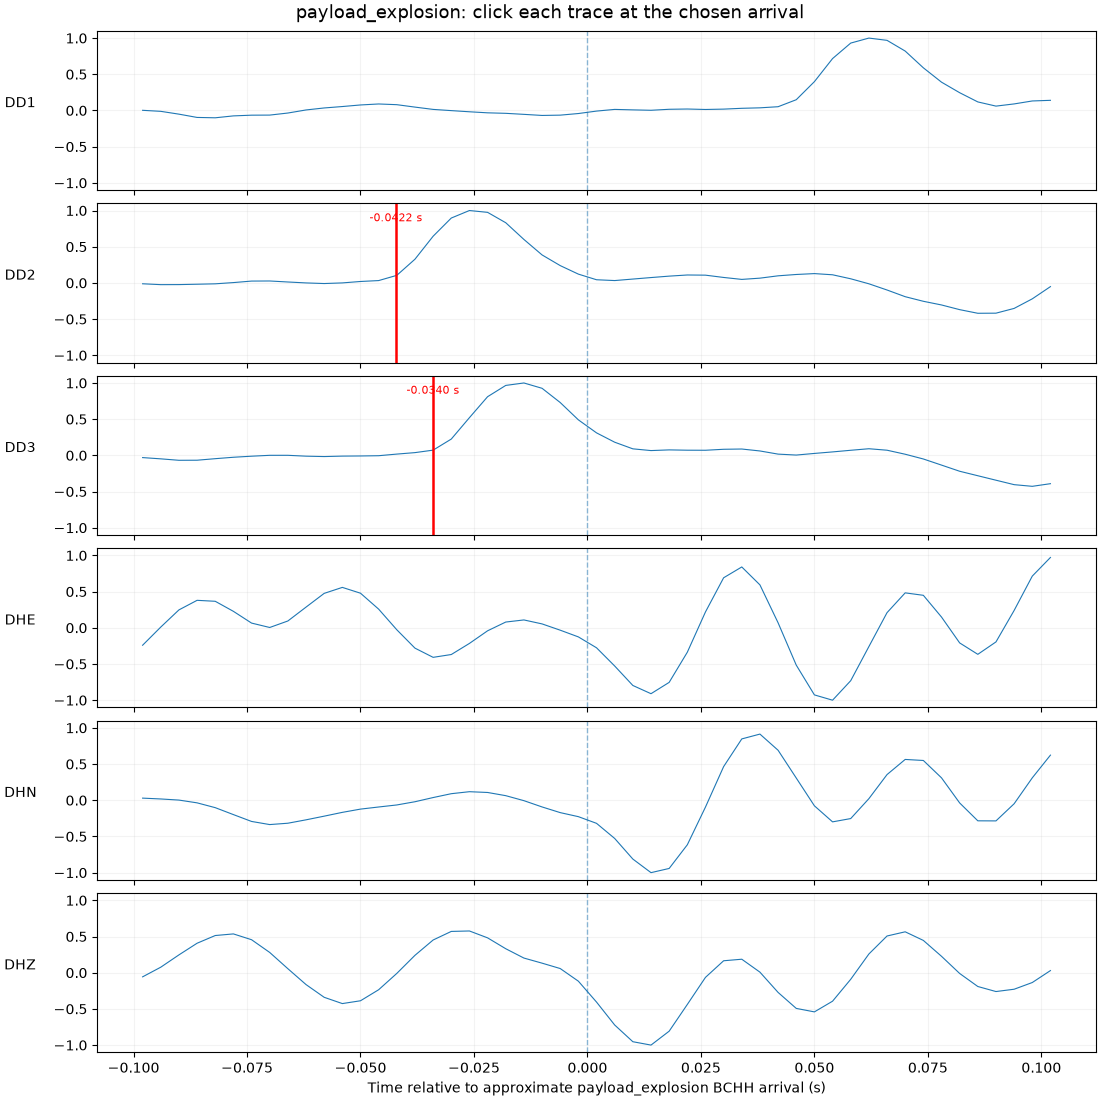

In [6]:

pick_store = {}


def picks_to_dataframe():
    columns = [
        "event", "trace_id", "sensor_kind",
        "pick_time_utc", "pick_epoch_s",
        "approx_event_centre_utc", "offset_from_plot_centre_s",
        "manual_uncertainty_s", "notes",
        "display_filter_applied", "display_filter_hz",
        "sampling_rate_hz", "picked_at_utc",
    ]

    if not pick_store:
        return pd.DataFrame(columns=columns)

    df = pd.DataFrame(list(pick_store.values()))
    event_order = [
        "upper_stage",
        "principal",
        "payload_impact",
        "payload_explosion",
    ]
    df["event"] = pd.Categorical(
        df["event"], categories=event_order, ordered=True
    )
    return df.sort_values(["trace_id", "event"]).reset_index(drop=True)


class SixTracePicker:
    def __init__(self, trace_ids, display_traces, event_centres):
        self.trace_ids = list(trace_ids)
        self.display_traces = display_traces
        self.event_centres = event_centres
        self.current_trace_id = None
        self.fig = None
        self.axes = None

        self.event_dropdown = widgets.Dropdown(
            options=list(event_centres.keys()),
            description="Event:",
            layout=widgets.Layout(width="420px"),
        )
        self.pre_box = widgets.FloatText(value=PRE_S, description="Pre (s):")
        self.post_box = widgets.FloatText(value=POST_S, description="Post (s):")
        self.unc_box = widgets.FloatText(
            value=0.010,
            description="Unc. (s):",
        )
        self.notes_box = widgets.Text(
            value="",
            description="Notes:",
            layout=widgets.Layout(width="700px"),
        )

        self.clear_trace_btn = widgets.Button(description="Clear current trace")
        self.clear_event_btn = widgets.Button(description="Clear event")
        self.save_btn = widgets.Button(
            description="Save picks",
            button_style="success",
        )
        self.status = widgets.HTML()

        self.event_dropdown.observe(self._event_changed, names="value")
        self.clear_trace_btn.on_click(self._clear_current_trace)
        self.clear_event_btn.on_click(self._clear_event)
        self.save_btn.on_click(self._save)

        display(
            widgets.HBox([
                self.event_dropdown,
                self.pre_box,
                self.post_box,
                self.unc_box,
            ]),
            self.notes_box,
            widgets.HBox([
                self.clear_trace_btn,
                self.clear_event_btn,
                self.save_btn,
            ]),
            self.status,
        )

        self.draw()

    @property
    def event_name(self):
        return self.event_dropdown.value

    def _event_changed(self, change):
        self.draw()

    def _clear_current_trace(self, _):
        if self.current_trace_id is None:
            self.status.value = "<b>Click a trace first.</b>"
            return
        pick_store.pop((self.event_name, self.current_trace_id), None)
        self.draw()

    def _clear_event(self, _):
        for tid in self.trace_ids:
            pick_store.pop((self.event_name, tid), None)
        self.draw()

    def _save(self, _):
        df = picks_to_dataframe()
        df.to_csv(PICKS_CSV, index=False)
        self.status.value = (
            f"<b>Saved {len(df)} picks</b> to "
            f"<code>{PICKS_CSV}</code>"
        )

    def _onclick(self, event):
        if event.inaxes is None or event.xdata is None:
            return

        axes_list = list(self.axes)
        if event.inaxes not in axes_list:
            return

        idx = axes_list.index(event.inaxes)
        tid = self.trace_ids[idx]
        self.current_trace_id = tid

        centre = self.event_centres[self.event_name]
        pick_time = UTCDateTime(
            centre.timestamp + float(event.xdata)
        )

        filt = (
            PRESSURE_FILTER_HZ
            if TRACE_KIND[tid] == "pressure"
            else SEISMIC_FILTER_HZ
        )

        pick_store[(self.event_name, tid)] = {
            "event": self.event_name,
            "trace_id": tid,
            "sensor_kind": TRACE_KIND[tid],
            "pick_time_utc": str(pick_time),
            "pick_epoch_s": float(pick_time.timestamp),
            "approx_event_centre_utc": str(centre),
            "offset_from_plot_centre_s": float(event.xdata),
            "manual_uncertainty_s": float(self.unc_box.value),
            "notes": self.notes_box.value,
            "display_filter_applied": bool(APPLY_DISPLAY_FILTER),
            "display_filter_hz": str(filt),
            "sampling_rate_hz": float(
                self.display_traces[tid].stats.sampling_rate
            ),
            "picked_at_utc": datetime.now(timezone.utc).isoformat(),
        }

        self.draw()

    def draw(self):
        if self.fig is not None:
            plt.close(self.fig)

        centre = self.event_centres[self.event_name]
        pre = float(self.pre_box.value)
        post = float(self.post_box.value)

        self.fig, self.axes = plt.subplots(
            6, 1,
            figsize=(11, 11),
            sharex=True,
            constrained_layout=True,
        )

        for ax, tid in zip(self.axes, self.trace_ids):
            tr = self.display_traces[tid].copy()
            tr.trim(centre - pre, centre + post, pad=False)

            if tr.stats.npts == 0:
                ax.text(
                    0.5, 0.5, "No data",
                    transform=ax.transAxes,
                    ha="center", va="center",
                )
                continue

            x = tr.times(reftime=centre)
            y = tr.data.astype(float)

            scale = np.nanmax(np.abs(y))
            yplot = y / scale if np.isfinite(scale) and scale > 0 else y

            ax.plot(x, yplot, lw=0.8)
            ax.axvline(0.0, ls="--", lw=1.0, alpha=0.5)
            ax.set_ylabel(
                tid.split(".")[-1],
                rotation=0,
                labelpad=24,
            )
            ax.set_ylim(-1.1, 1.1)
            ax.grid(alpha=0.15)

            saved = pick_store.get((self.event_name, tid))
            if saved is not None:
                xp = saved["pick_epoch_s"] - centre.timestamp
                ax.axvline(xp, lw=1.8, color="red")
                ax.text(
                    xp, 0.94,
                    f"{xp:+.4f} s",
                    transform=ax.get_xaxis_transform(),
                    ha="center", va="top",
                    fontsize=8, color="red",
                )

        self.axes[-1].set_xlabel(
            f"Time relative to approximate {self.event_name} "
            "BCHH arrival (s)"
        )
        self.fig.suptitle(
            f"{self.event_name}: click each trace at the chosen arrival",
            fontsize=13,
        )
        self.fig.canvas.mpl_connect(
            "button_press_event",
            self._onclick,
        )

        n = sum(
            (self.event_name, tid) in pick_store
            for tid in self.trace_ids
        )
        self.status.value = (
            f"<b>{self.event_name}</b>: {n}/6 traces picked. "
            "Red = manual pick; dashed = approximate centre."
        )

        plt.show()


if len(TRACE_IDS) == 6:
    picker = SixTracePicker(
        TRACE_IDS,
        display_traces,
        EVENTS,
    )
else:
    print("Set TRACE_IDS first, then rerun Sections 4 and 5.")


## 6. Save/view the pick DataFrame

In [ ]:

picks_df = picks_to_dataframe()
display(picks_df)

if len(picks_df):
    picks_df.to_csv(PICKS_CSV, index=False)
    print("Saved:", PICKS_CSV)



## 7. Same-trace differential arrival times

These are the key quantities for comparing source-event spacing from the video
with event-arrival spacing at BCHH.


In [ ]:

EVENT_ORDER = [
    "upper_stage",
    "principal",
    "payload_impact",
    "payload_explosion",
]


def build_interval_dataframe(picks_df):
    if picks_df.empty:
        return pd.DataFrame()

    wide = (
        picks_df
        .pivot(index="trace_id", columns="event", values="pick_epoch_s")
        .reindex(columns=EVENT_ORDER)
    )

    interval_defs = [
        ("principal_minus_upper", "upper_stage", "principal"),
        ("impact_minus_upper", "upper_stage", "payload_impact"),
        (
            "payload_explosion_minus_upper",
            "upper_stage",
            "payload_explosion",
        ),
        ("impact_minus_principal", "principal", "payload_impact"),
        (
            "payload_explosion_minus_impact",
            "payload_impact",
            "payload_explosion",
        ),
    ]

    rows = []
    for tid, row in wide.iterrows():
        for name, e0, e1 in interval_defs:
            t0 = row.get(e0, np.nan)
            t1 = row.get(e1, np.nan)
            if np.isfinite(t0) and np.isfinite(t1):
                rows.append({
                    "trace_id": tid,
                    "sensor_kind": TRACE_KIND.get(tid, ""),
                    "interval_name": name,
                    "event_0": e0,
                    "event_1": e1,
                    "dt_s": float(t1 - t0),
                })

    return pd.DataFrame(rows)


intervals_df = build_interval_dataframe(picks_df)
display(intervals_df)

if len(intervals_df):
    intervals_df.to_csv(INTERVALS_CSV, index=False)
    print("Saved:", INTERVALS_CSV)


## 8. Robust summaries across channels

In [ ]:

def robust_summary_values(x):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)

    if len(x) == 0:
        return {
            "n": 0,
            "median_s": np.nan,
            "mean_s": np.nan,
            "std_s": np.nan,
            "mad_s": np.nan,
            "robust_sigma_s": np.nan,
            "min_s": np.nan,
            "max_s": np.nan,
        }

    med = np.median(x)
    mad = np.median(np.abs(x - med))

    return {
        "n": len(x),
        "median_s": med,
        "mean_s": np.mean(x),
        "std_s": np.std(x, ddof=1) if len(x) > 1 else np.nan,
        "mad_s": mad,
        "robust_sigma_s": 1.4826 * mad,
        "min_s": np.min(x),
        "max_s": np.max(x),
    }


def summarize_intervals(intervals_df, by_kind=False):
    if intervals_df.empty:
        return pd.DataFrame()

    group_cols = ["interval_name"]
    if by_kind:
        group_cols.append("sensor_kind")

    rows = []
    for keys, grp in intervals_df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row.update(robust_summary_values(grp["dt_s"]))
        rows.append(row)

    return pd.DataFrame(rows)


summary_all = summarize_intervals(intervals_df, by_kind=False)
summary_by_kind = summarize_intervals(intervals_df, by_kind=True)

print("All six traces:")
display(summary_all)

print("Pressure versus seismic:")
display(summary_by_kind)

if len(summary_all):
    summary_all.to_csv(SUMMARY_CSV, index=False)
    print("Saved:", SUMMARY_CSV)



## 9. Compare with independent video intervals

Once the video timing is finalized, enter the source-event intervals below.

For the first-stage minus second-stage pair, the current 60-fps SpaceX camera
estimate discussed separately is approximately 3.6667 s.

A positive value of

`video interval - BCHH arrival interval`

means the later event had a shorter travel time to BCHH than the earlier event.


In [ ]:

VIDEO_INTERVALS_S = {
    # "principal_minus_upper": 3.6667,
}

if len(intervals_df) and VIDEO_INTERVALS_S:
    bchh = (
        intervals_df
        .groupby("interval_name")["dt_s"]
        .median()
        .rename("bchh_median_interval_s")
        .to_frame()
    )

    bchh["video_interval_s"] = pd.Series(VIDEO_INTERVALS_S)
    bchh["differential_travel_time_s"] = (
        bchh["video_interval_s"]
        - bchh["bchh_median_interval_s"]
    )

    display(bchh.dropna())



## Recommended picking strategy

- Pick each channel independently.
- Use the same physical phase consistently between events on each trace.
- Prefer a first unambiguous impulsive onset rather than the absolute maximum.
- Make a first pass through all 24 picks and save it.
- Then clear the picks and make a second pass. The difference between passes is
  a direct estimate of manual repeatability.
- Inspect pressure and seismic interval summaries separately before combining
  all six traces.
- Do not convert these picks to source times until the differential arrival
  intervals have been checked. The differential intervals are the least
  model-dependent product.
